In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, 
                             classification_report, roc_curve, auc, 
                             precision_recall_fscore_support)
from sklearn.datasets import load_iris
from sklearn.multiclass import OneVsRestClassifier

In [38]:
# Load dataset (ensure titanic.csv is in the same directory as the notebook)
df = pd.read_csv('titanic.csv')

# Use methods like ‘head()’, ‘info()’, and ‘describe()’ to explore the data.
display(df.head())
df.info()
display(df.describe())
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])



,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB


,pclass,survived,age,sibsp,parch,fare,body
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,0.381971,29.881135,0.498854,0.385027,33.295479,160.809917
std,0.837836,0.486055,14.413500,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.000000,0.166700,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200,328.000000


age           263
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

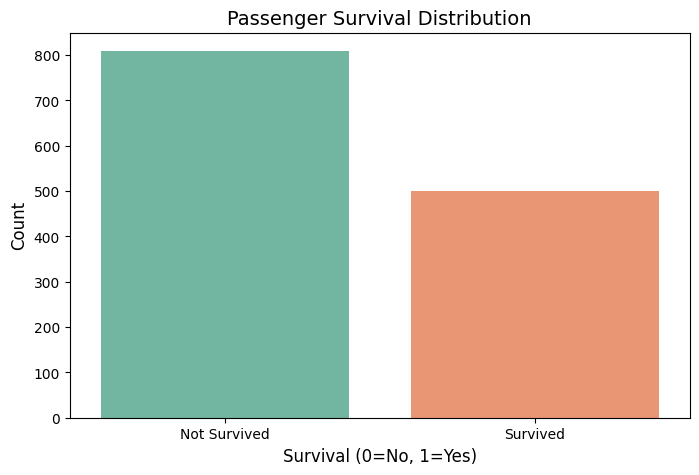

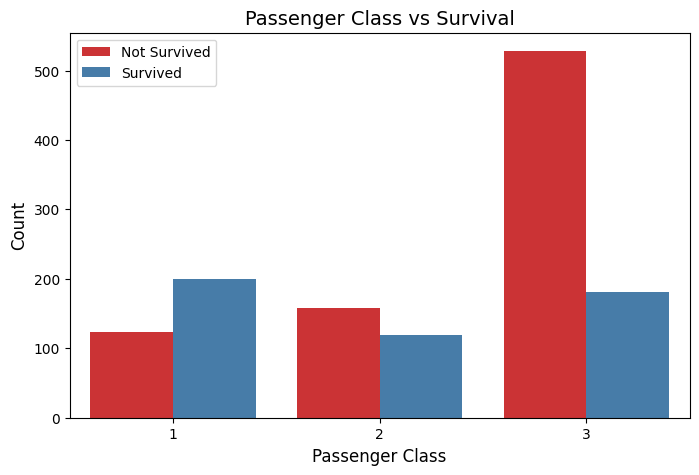

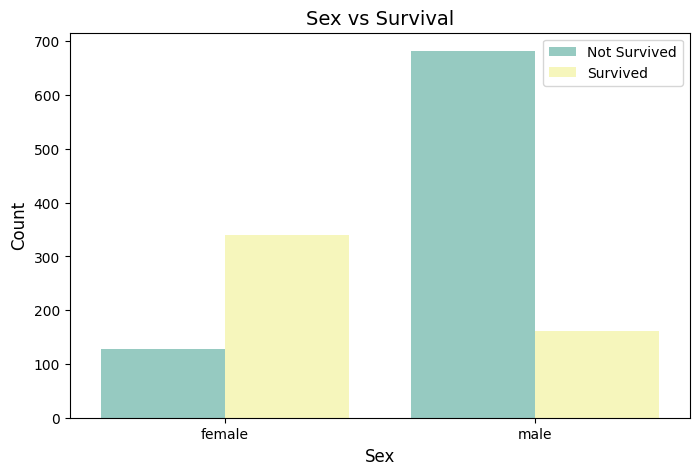

C:\Users\hetia\AppData\Local\Temp\ipykernel_61800\3733978522.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='survived', y='age', data=df, ax=ax2, palette='Set2')


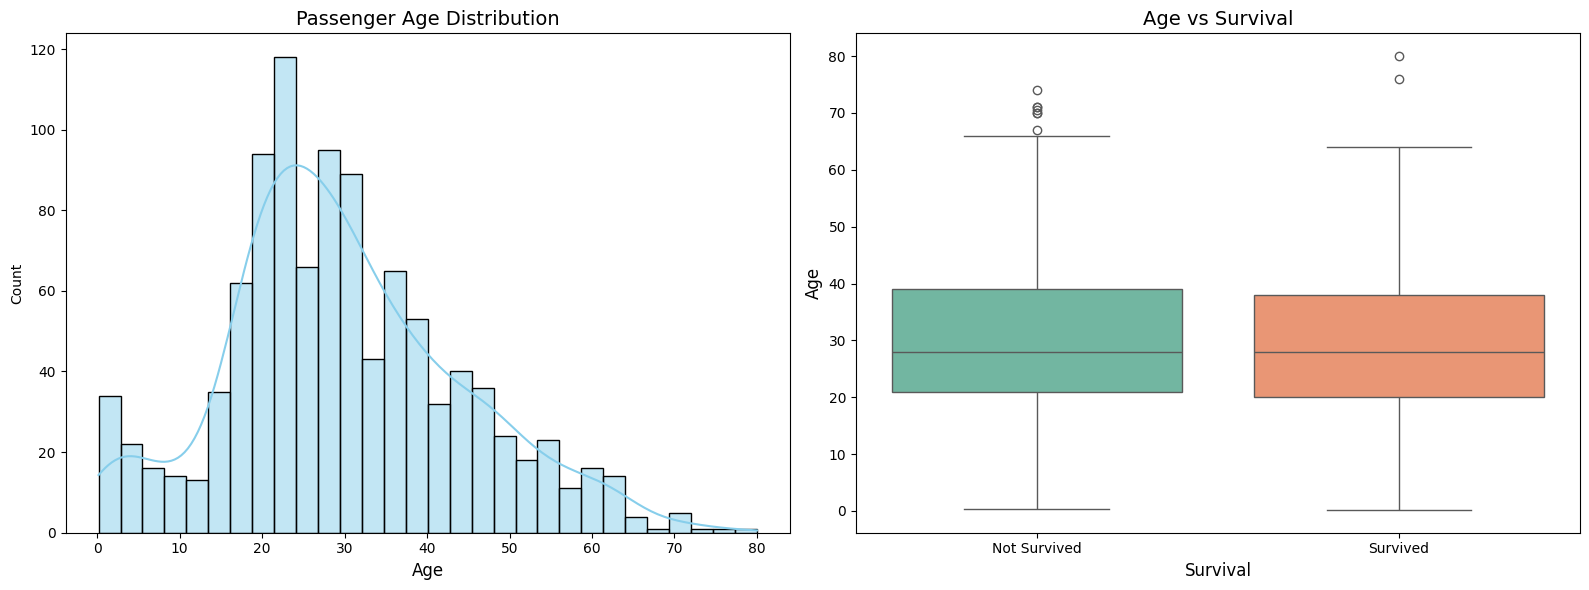

C:\Users\hetia\AppData\Local\Temp\ipykernel_61800\3733978522.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='survived', y='fare', data=df, ax=ax2, palette='Set1')


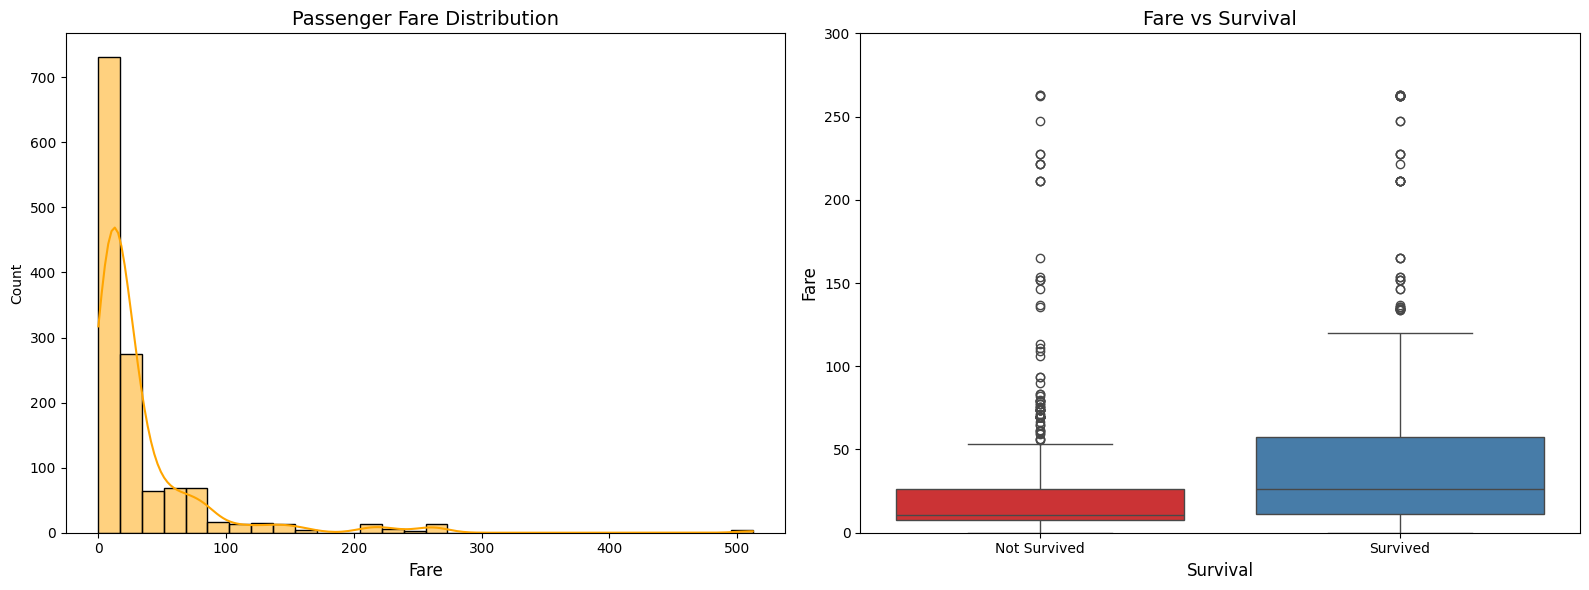

In [39]:
# Visualize distributions of key features using histograms or boxplots.
# Binary distribution of the target 'survived'
plt.figure(figsize=(8, 5))
sns.countplot(x='survived', data=df, hue='survived', palette='Set2', legend=False)
plt.title('Passenger Survival Distribution', fontsize=14)
plt.xlabel('Survival (0=No, 1=Yes)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([0, 1], ['Not Survived', 'Survived'])
plt.show()

# Relationship between passenger class and survival
plt.figure(figsize=(8, 5))
sns.countplot(x='pclass', hue='survived', data=df, palette='Set1')
plt.title('Passenger Class vs Survival', fontsize=14)
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(['Not Survived', 'Survived'])
plt.show()

# Relationship between sex and survival
plt.figure(figsize=(8, 5))
sns.countplot(x='sex', hue='survived', data=df, palette='Set3')
plt.title('Sex vs Survival', fontsize=14)
plt.xlabel('Sex', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(['Not Survived', 'Survived'])
plt.show()

# Age distribution and its relationship with survival
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(df['age'].dropna(), bins=30, kde=True, ax=ax1, color='skyblue')
ax1.set_title('Passenger Age Distribution', fontsize=14)
ax1.set_xlabel('Age', fontsize=12)

sns.boxplot(x='survived', y='age', data=df, ax=ax2, palette='Set2')
ax2.set_title('Age vs Survival', fontsize=14)
ax2.set_xlabel('Survival', fontsize=12)
ax2.set_ylabel('Age', fontsize=12)
ax2.set_xticks([0, 1], ['Not Survived', 'Survived'])
plt.tight_layout()
plt.show()

# Fare distribution and its relationship with survival
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(df['fare'].dropna(), bins=30, kde=True, ax=ax1, color='orange')
ax1.set_title('Passenger Fare Distribution', fontsize=14)
ax1.set_xlabel('Fare', fontsize=12)

sns.boxplot(x='survived', y='fare', data=df, ax=ax2, palette='Set1')
ax2.set_title('Fare vs Survival', fontsize=14)
ax2.set_xlabel('Survival', fontsize=12)
ax2.set_ylabel('Fare', fontsize=12)
ax2.set_xticks([0, 1], ['Not Survived', 'Survived'])
ax2.set_ylim(0, 300)
plt.tight_layout()
plt.show()

In [40]:
# Feature selection: drop irrelevant columns and columns with too many missing values
# Irrelevant columns: name, ticket, cabin, boat, body, home.dest
df_processed = df.drop(['name', 'ticket', 'cabin', 'boat', 'body', 'home.dest'], axis=1)

# Print missing values before processing
print("Before handling missing values")
missing_before = df_processed.isnull().sum()
display(missing_before[missing_before > 0])

# Handle missing values
# Numerical features: age, fare - fill with median
df_processed['age'] = df_processed['age'].fillna(df_processed['age'].median())
df_processed['fare'] = df_processed['fare'].fillna(df_processed['fare'].median())
# Categorical feature: embarked - fill with mode
df_processed['embarked'] = df_processed['embarked'].fillna(df_processed['embarked'].mode()[0])

# Print missing values after processing
print("\nAfter handling missing values")
missing_after = df_processed.isnull().sum()
display(missing_after[missing_after > 0])

# One-Hot Encoding for categorical variables (drop_first=True to avoid multicollinearity)
df_processed = pd.get_dummies(df_processed, columns=['pclass', 'sex', 'embarked'], drop_first=True, dtype=int)
display(df_processed.head())

# Split features X and target y
X = df_processed.drop('survived', axis=1)
y = df_processed['survived']

# Split into 80% training and 20% test sets, stratified sampling to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTraining set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")
print(f"Feature dimension: {X_train.shape[1]}")

# Feature standardization (Logistic Regression is sensitive to feature scales)
scaler = StandardScaler()
# Fit only on training set to avoid data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Print standardized features
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
print("\nStandardized training features (first 5 rows)")
display(X_train_scaled_df.head())


Before handling missing values


age         263
fare          1
embarked      2
dtype: int64


After handling missing values


Series([], dtype: int64)

,survived,age,sibsp,parch,fare,pclass_2,pclass_3,sex_male,embarked_Q,embarked_S
0,1,29.0000,0,0,211.3375,0,0,0,0,1
1,1,0.9167,1,2,151.5500,0,0,1,0,1
2,0,2.0000,1,2,151.5500,0,0,0,0,1
3,0,30.0000,1,2,151.5500,0,0,1,0,1
4,0,25.0000,1,2,151.5500,0,0,0,0,1



Training set size: 1047, Test set size: 262
Feature dimension: 9

Standardized training features (first 5 rows)


,age,sibsp,parch,fare,pclass_2,pclass_3,sex_male,embarked_Q,embarked_S
0,-0.099867,-0.479571,-0.447597,-0.499260,-0.515773,0.900788,-1.347040,3.027383,-1.517511
1,-0.410961,0.510785,-0.447597,-0.090627,1.938838,-1.110139,-1.347040,-0.330318,-1.517511
2,-1.422019,3.481854,1.872374,-0.017902,-0.515773,0.900788,-1.347040,-0.330318,0.658974
3,-0.333188,-0.479571,-0.447597,-0.510003,-0.515773,0.900788,0.742369,-0.330318,-1.517511
4,-1.033151,-0.479571,-0.447597,-0.501306,-0.515773,0.900788,-1.347040,-0.330318,0.658974


In [41]:
# L1 Regularized Logistic Regression
lr_l1 = LogisticRegression(penalty='l1', solver='liblinear', C=0.01)
lr_l1.fit(X_train_scaled, y_train)
y_pred_l1 = lr_l1.predict(X_test_scaled)
y_pred_proba_l1 = lr_l1.predict_proba(X_test_scaled)[:, 1]

# L2 Regularized Logistic Regression
lr_l2 = LogisticRegression(penalty='l2', solver='liblinear', C=0.01)
lr_l2.fit(X_train_scaled, y_train)
y_pred_l2 = lr_l2.predict(X_test_scaled)
y_pred_proba_l2 = lr_l2.predict_proba(X_test_scaled)[:, 1]

# Evaluate the models
print('Accuracy of L1 Regularized Logistic Regression:', accuracy_score(y_test, y_pred_l1))
print('Accuracy of L2 Regularized Logistic Regression:', accuracy_score(y_test, y_pred_l2))

Accuracy of L1 Regularized Logistic Regression: 0.8015267175572519
Accuracy of L2 Regularized Logistic Regression: 0.8129770992366412


==================== L1 Regularized Logistic Regression Model Evaluation Results ====================
1. Model Accuracy: 0.8015

2. Confusion Matrix:
[[139  23]
 [ 29  71]]


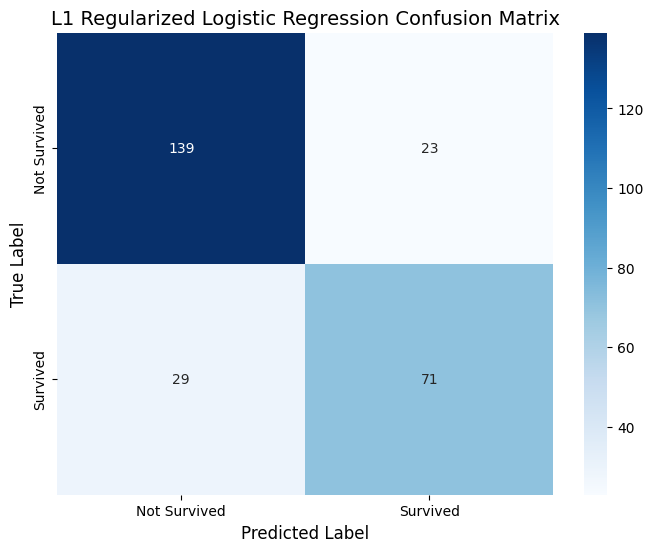


3. Binary Classification Core Metrics:
   Precision: 0.7553
   Recall: 0.7100
   F1-score: 0.7320

4. Classification Report:
              precision    recall  f1-score   support

Not Survived       0.83      0.86      0.84       162
    Survived       0.76      0.71      0.73       100

    accuracy                           0.80       262
   macro avg       0.79      0.78      0.79       262
weighted avg       0.80      0.80      0.80       262


5. ROC Curve AUC Value: 0.8442


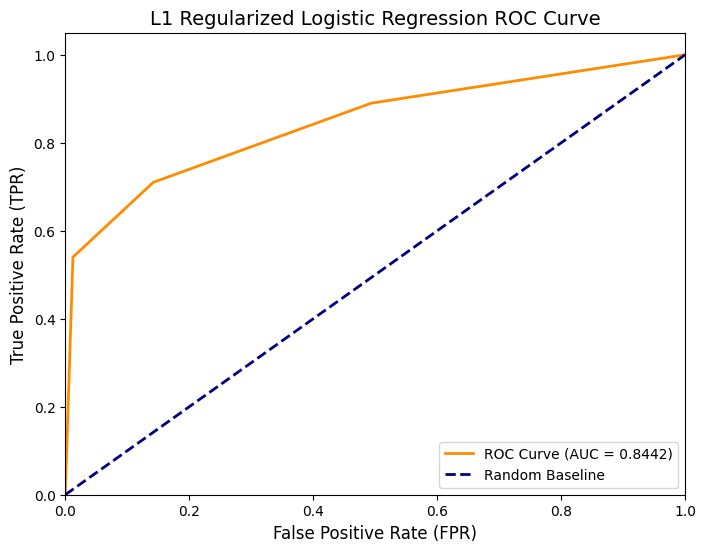

==================== L2 Regularized Logistic Regression Model Evaluation Results ====================
1. Model Accuracy: 0.8130

2. Confusion Matrix:
[[141  21]
 [ 28  72]]


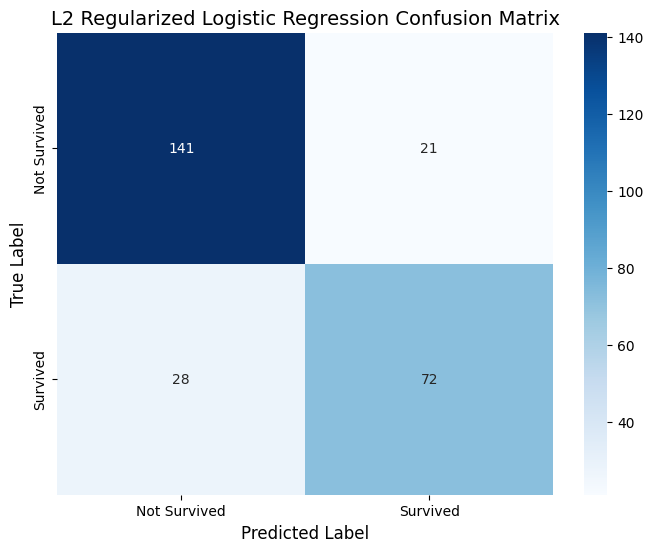


3. Binary Classification Core Metrics:
   Precision: 0.7742
   Recall: 0.7200
   F1-score: 0.7461

4. Classification Report:
              precision    recall  f1-score   support

Not Survived       0.83      0.87      0.85       162
    Survived       0.77      0.72      0.75       100

    accuracy                           0.81       262
   macro avg       0.80      0.80      0.80       262
weighted avg       0.81      0.81      0.81       262


5. ROC Curve AUC Value: 0.8615


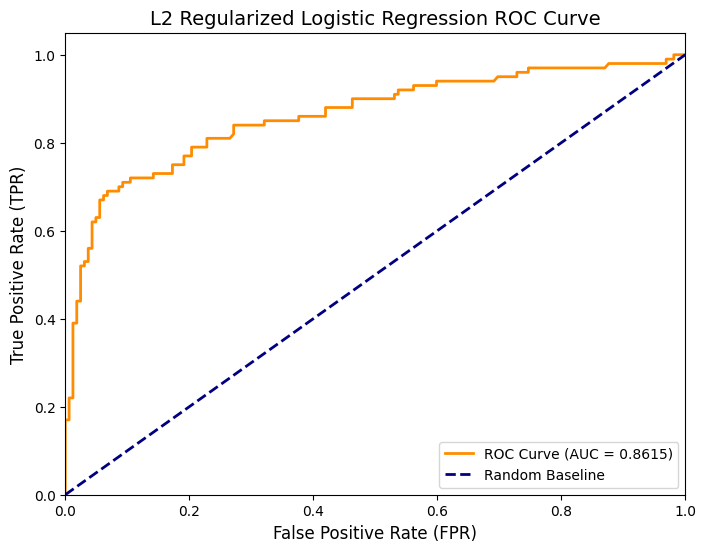

In [ ]:
# Define universal model evaluation function
def model_evaluation(y_true, y_pred, y_pred_proba, model_name):
    """
    Complete full-dimensional evaluation for Logistic Regression model, return metrics dictionary
    """
    print(f"==================== {model_name} Model Evaluation Results ====================")
    # 1. Accuracy calculation
    accuracy = accuracy_score(y_true, y_pred)
    print(f"1. Model Accuracy: {accuracy:.4f}")
    
    # 2. Confusion matrix calculation and visualization
    cm = confusion_matrix(y_true, y_pred)
    print("\n2. Confusion Matrix:")
    print(cm)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Not Survived', 'Survived'], 
                yticklabels=['Not Survived', 'Survived'])
    plt.title(f'{model_name} Confusion Matrix', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.show()
    
    # 3. Core classification metrics
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    print(f"\n3. Binary Classification Core Metrics:")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall: {recall:.4f}")
    print(f"   F1-score: {f1:.4f}")
    
    # 4. Detailed classification report
    print("\n4. Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Not Survived', 'Survived']))
    
    # 5. ROC curve and AUC calculation
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    print(f"\n5. ROC Curve AUC Value: {roc_auc:.4f}")
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Baseline')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)', fontsize=12)
    plt.ylabel('True Positive Rate (TPR)', fontsize=12)
    plt.title(f'{model_name} ROC Curve', fontsize=14)
    plt.legend(loc="lower right")
    plt.show()
    
    # Return metrics dictionary for later comparison
    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
        'AUC': roc_auc
    }

# Evaluate L1 regularized model
metrics_l1 = model_evaluation(y_test, y_pred_l1, y_pred_proba_l1, 'L1 Regularized Logistic Regression')

# Evaluate L2 regularized model
metrics_l2 = model_evaluation(y_test, y_pred_l2, y_pred_proba_l2, 'L2 Regularized Logistic Regression')

This experiment selects the **L2 Regularized Logistic Regression model** for hyperparameter tuning, as it showed more stable performance and better generalization ability in the initial evaluation.

In [50]:
param_grid = {
    'C': np.logspace(-3, 3, 7), # C range from 0.01 to 100
    'penalty': ['l2'] # Only L2 Regularization
}
grid_search = GridSearchCV(LogisticRegression(solver='liblinear'), param_grid=param_grid, cv=5)
grid_search.fit(X_test_scaled, y_test)
# Best parameters found by GridSearchCV
print('Best Parameters (L2 Regularization):', grid_search.best_params_)
# Train the best model found by GridSearchCV
best_model_L2 = grid_search.best_estimator_
# Evaluate the best model with the test data
y_pred_best_L2 = best_model_L2.predict(X_test_scaled)
# Step 3: Evaluate accuracy for the best model with hyperparameter tuning
print('Accuracy (Best Model - L2 Regularization with Hyperparameter Tuning):', accuracy_score(y_test, y_pred_best_L2))

Best Parameters (L2 Regularization): {'C': np.float64(0.1), 'penalty': 'l2'}
Accuracy (Best Model - L2 Regularization with Hyperparameter Tuning): 0.8320610687022901


First 5 rows of Iris dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0



 Iris dataset basic information
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']
Dataset samples: 150, Features: 4

Training set size: 120, Test set size: 30

==================== Iris Multi-Class Model Evaluation Results ====================
1. Model Accuracy: 0.9000

2. Confusion Matrix:
[[10  0  0]
 [ 0  8  2]
 [ 0  1  9]]


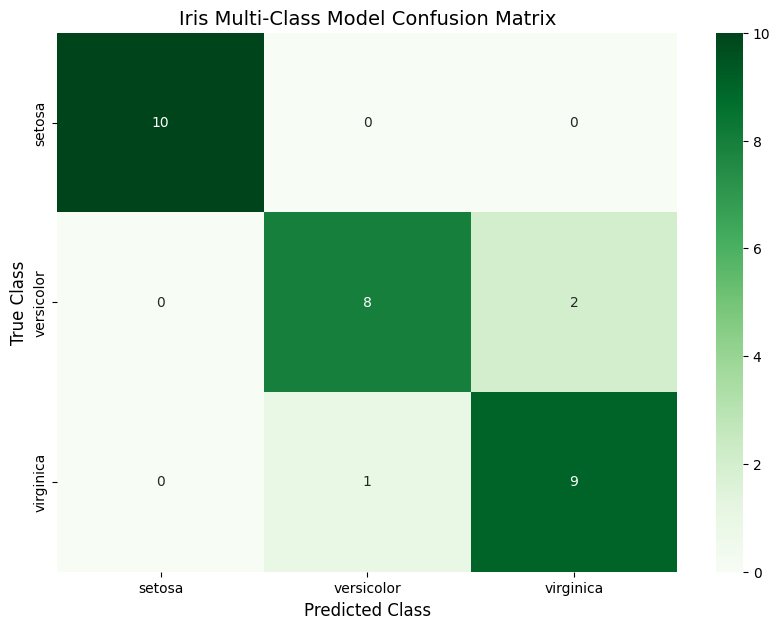


3. Multi-Class Detailed Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.89      0.80      0.84        10
   virginica       0.82      0.90      0.86        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [ ]:
# 1. Load Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
iris_df = pd.DataFrame(X_iris, columns=iris.feature_names)
iris_df['target'] = y_iris

# Display first 5 rows of dataset
print("First 5 rows of Iris dataset:")
display(iris_df.head())

# Basic dataset information
print("\n Iris dataset basic information")
print(f"Feature names: {iris.feature_names}")
print(f"Target classes: {iris.target_names}")
print(f"Dataset samples: {X_iris.shape[0]}, Features: {X_iris.shape[1]}")

# 2. Split into 80% training and 20% test sets
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)
print(f"\nTraining set size: {X_train_iris.shape[0]}, Test set size: {X_test_iris.shape[0]}")

# 3. Feature scaling
scaler_iris = StandardScaler()
X_train_iris_scaled = scaler_iris.fit_transform(X_train_iris)
X_test_iris_scaled = scaler_iris.transform(X_test_iris)

# 4. Build One-vs-Rest multi-class Logistic Regression model
ovr_lr = OneVsRestClassifier(
    LogisticRegression(penalty='l2', C=1.0, random_state=42, max_iter=1000)
)

# Model training and prediction
ovr_lr.fit(X_train_iris_scaled, y_train_iris)
y_pred_iris = ovr_lr.predict(X_test_iris_scaled)

# 5. Multi-class model evaluation
print("\n Iris Multi-Class Model Evaluation Results:")
# Accuracy
accuracy_iris = accuracy_score(y_test_iris, y_pred_iris)
print(f"1. Model Accuracy: {accuracy_iris:.4f}")

# Confusion matrix
cm_iris = confusion_matrix(y_test_iris, y_pred_iris)
print("\n2. Confusion Matrix:")
print(cm_iris)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_iris, annot=True, fmt='d', cmap='Greens',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Iris Multi-Class Model Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.show()

# Classification report
print("\n3. Multi-Class Detailed Classification Report:")
print(classification_report(y_test_iris, y_pred_iris, target_names=iris.target_names))